# **Climate Forecasting using Machine Learning: 07 Horizon Transfer**

---

### **Notebook Summary**

This notebook carries forward the best model settings selected in the previous notebooks and tests how those fixed settings behave as forecast lead time increases. The retained model set and H=1 tuned parameters are reused rather than retuned, so the experiment measures horizon transfer rather than another model-selection or ensemble-selection step.

### **Horizon transfer settings**
- horizons H = 1, 2, 3, 6, and 12
- best tuned setting for every retained model loaded from notebook 05
- residual target construction carried forward from the prior design notebooks
- AR + current ENSO features
- SST off
- no horizon-specific model retuning
- selected residual models compared directly at each horizon
- random seed = 42

### **What this notebook should answer**
1. Which previously selected model settings transfer best as H increases?
2. Do deep-learning and classical/statistical model differences persist at longer lead times?
3. How quickly does forecast error change as horizon grows?
4. Is one selected model setting consistently strong, or do winners vary by horizon?

---

# **Part 1: Configuration**

### **Imports**

In [1]:
from pathlib import Path
import ast
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start: Path) -> Path:
    return next(
        candidate
        for candidate in [start, *start.parents]
        if (candidate / "src" / "forecaster" / "__init__.py").exists()
    )


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
sys.path.insert(0, str(SRC_DIR))


def project_relative(path):
    return Path(path).resolve().relative_to(PROJECT_ROOT).as_posix()


def portable_config(config):
    portable = dict(vars(config)) if hasattr(config, "__dict__") else dict(config)

    for key in ("tavg_file", "sst_dir", "enso_csv"):
        if key in portable and portable[key] is not None:
            portable[key] = project_relative(portable[key])

    return portable


from forecaster.config import ForecasterConfig
from forecaster.data.sources import load_land_series_and_anoms, load_enso_monthly
from forecaster.ml.core import (
    build_features_and_target,
    train_predict_models,
    make_recency_weights,
)
from forecaster.ml.evaluation import rmse, mae, bias, overall_table


pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 180)

print("Repository setup complete.")
print("Import path: src")

Repository setup complete.


### **Figure export helper**


In [2]:
IMAGE_DIR = PROJECT_ROOT / "experiment_notebooks/Experiment_Images_For_Case_Analysis"
IMAGE_DIR.mkdir(parents=True, exist_ok=True)


def save_current_plot(filename: str, *, dpi: int = 180):
    path = IMAGE_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print("Saved figure:", path.relative_to(PROJECT_ROOT))
    return path


print("Case-analysis image folder:", IMAGE_DIR.relative_to(PROJECT_ROOT))

Case-analysis image folder: experiment_notebooks/Experiment_Images_For_Case_Analysis


### **Configurations**

This cell defines the fixed design carried forward from the previous notebooks and the forecast horizons to test. The best tuned setting for every retained model is reused rather than retuned for each horizon.

In [3]:
DATA_DIR = PROJECT_ROOT / "noaa_raw_data"
TAVG_FILE = str(DATA_DIR / "nclimgrid_tavg.nc")
SST_DIR = str(DATA_DIR / "sst_cache")
ENSO_CSV = str(DATA_DIR / "nina34.anom.csv")
RANDOM_SEED = 42
OUTPUT_DIR = PROJECT_ROOT / "notebooks_outputs"
SELECTED_SETTINGS_PATH = OUTPUT_DIR / "05_h1_enso_model_hypertuning_selected_model_settings.csv"

SELECTED_AR_LAGS = (1, 2, 3, 6, 12, 18, 24)
ENSO_LAG_OPTION = "enso_0"
ENSO_LAGS = (0,)
CLIMATOLOGY_YEARS = 18
HORIZONS = [1, 2, 3, 6, 12]
DEEP_INTERNAL_VAL_MONTHS = 24
OUTPUT_PREFIX = "07_horizon_transfer_selected_model_settings"

RESEARCH_MODEL_SET = [
    "Ridge",
    "Huber",
    "XGBoost",
    "LSTM",
    "PatchTST",
    "iTransformer",
    "NHiTS",
]


BASE_CFG_TEMPLATE = dict(
    tavg_file=TAVG_FILE,
    sst_dir=SST_DIR,
    enso_csv=ENSO_CSV,
    random_seed=RANDOM_SEED,
    enso_lags=ENSO_LAGS,
    use_sst=False,
    use_teleconnections=False,
    use_qmap=False,
    use_month_alpha_choice=False,
    month_group_size=12,
    use_ridge=True,
    use_xgb=True,
    use_huber=True,
    use_lstm=True,
    use_patchtst=True,
    use_itransformer=True,
    use_nhits=True,
    use_recency_weights=True,
    half_life_months=48,
    residual_deseasonalize=False,
    ar_lags=SELECTED_AR_LAGS,
    plot_test=False,
    verbose=True,
)

EVALUATION_MONTH_GROUPS = {
    "G01_12": list(range(1, 13)),
}

MODEL_TOGGLE_FIELDS = {
    "Ridge": "use_ridge",
    "Huber": "use_huber",
    "XGBoost": "use_xgb",
    "LSTM": "use_lstm",
    "PatchTST": "use_patchtst",
    "iTransformer": "use_itransformer",
    "NHiTS": "use_nhits",
}

DEEP_MODELS = {"LSTM", "PatchTST", "iTransformer", "NHiTS"}

print("Selected settings file exists:", SELECTED_SETTINGS_PATH.exists())
print("ENSO CSV exists:", Path(ENSO_CSV).exists())
print("ENSO option:", ENSO_LAG_OPTION, ENSO_LAGS)
print("Selected AR lags:", SELECTED_AR_LAGS)
print("Recency half-life months:", BASE_CFG_TEMPLATE["half_life_months"])
print("Horizons:", HORIZONS)
portable_config(BASE_CFG_TEMPLATE)

Selected settings file exists: True
ENSO CSV exists: True
ENSO option: enso_0 (0,)
Selected AR lags: (1, 2, 3, 6, 12, 18, 24)
Recency half-life months: 48
Horizons: [1, 2, 3, 6, 12]


{'tavg_file': 'nclimgrid_tavg.nc',
 'sst_dir': 'sst_cache',
 'enso_csv': 'nina34.anom.csv',
 'random_seed': 42,
 'enso_lags': (0,),
 'use_sst': False,
 'use_teleconnections': False,
 'use_qmap': False,
 'use_month_alpha_choice': False,
 'month_group_size': 12,
 'use_ridge': True,
 'use_xgb': True,
 'use_huber': True,
 'use_lstm': True,
 'use_patchtst': True,
 'use_itransformer': True,
 'use_nhits': True,
 'use_recency_weights': True,
 'half_life_months': 48,
 'residual_deseasonalize': False,
 'ar_lags': (1, 2, 3, 6, 12, 18, 24),
 'plot_test': False,
 'verbose': True}

### **Helper functions**

These helpers rebuild the residual forecasting problem for each horizon and refit the selected model settings. Notebook 07 reports direct selected-model performance across horizons.

In [4]:
import importlib
import forecaster.experiments as experiments

experiments = importlib.reload(experiments)

_evaluate_horizon = experiments.evaluate_horizon
load_selected_settings = experiments.load_selected_settings


def evaluate_horizon(horizon: int, selected_params: dict, climatology_years: int = CLIMATOLOGY_YEARS):
    return _evaluate_horizon(
        BASE_CFG_TEMPLATE,
        horizon=horizon,
        selected_params=selected_params,
        month_groups=EVALUATION_MONTH_GROUPS,
        climatology_years=climatology_years,
        metadata={
            "enso_option": ENSO_LAG_OPTION,
            "enso_lags": str(ENSO_LAGS),
            "ar_lags": str(SELECTED_AR_LAGS),
            "recency_half_life_months": BASE_CFG_TEMPLATE["half_life_months"],
        },
        deep_internal_val_months=DEEP_INTERNAL_VAL_MONTHS,
    )

### **Load notebook 05 choices**

This section loads the tuned model settings selected at H=1. Reusing them tests whether the H=1 recipe transfers to longer lead times.

In [5]:
selected_settings_df, selected_params = load_selected_settings(SELECTED_SETTINGS_PATH)

selected_settings_df = (
    selected_settings_df[
        selected_settings_df["model"].isin(RESEARCH_MODEL_SET)
    ]
    .copy()
)

selected_settings_df["model"] = pd.Categorical(
    selected_settings_df["model"],
    categories=RESEARCH_MODEL_SET,
    ordered=True,
)

selected_settings_df = (
    selected_settings_df
    .sort_values("model")
    .reset_index(drop=True)
)

selected_settings_df["model"] = selected_settings_df["model"].astype(str)

selected_params = {
    model: selected_params[model]
    for model in selected_settings_df["model"]
}

print("Loaded tuned settings from notebook 05:")
display(
    selected_settings_df[
        [
            "model",
            "option",
            "params",
            "enso_option",
            "enso_lags",
            "ar_lags",
            "recency_half_life_months",
        ]
    ]
)

Loaded tuned settings from notebook 05:


,model,option,params,enso_option,enso_lags,ar_lags,recency_half_life_months
0,Ridge,alpha_1,{'ridge_alpha': 1.0},enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48
1,Huber,looser,"{'huber_epsilon': 1.6, 'huber_alpha': 0.001}",enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48
2,XGBoost,conservative,"{'xgb_n_estimators': 600, 'xgb_learning_rate':...",enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48
3,LSTM,compact,"{'torch_seq_hidden_size': 24, 'torch_seq_num_l...",enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48
4,PatchTST,deeper,"{'torch_patch_len': 4, 'torch_patch_stride': 2...",enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48
5,iTransformer,deeper,"{'torch_itransformer_d_model': 48, 'torch_itra...",enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48
6,NHiTS,wide,"{'torch_nhits_hidden_size': 96, 'torch_nhits_n...",enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48


---

# **Part 2: Run the horizon sweep**


In [6]:
horizon_results = {}
summary_frames = []
choice_candidate_frames = []
refit_frames = []

for horizon in HORIZONS:
    print("=" * 100)
    print(f"Evaluating selected model settings at H={horizon}")
    result = evaluate_horizon(
        horizon=horizon,
        selected_params=selected_params,
        climatology_years=CLIMATOLOGY_YEARS,
    )
    horizon_results[int(horizon)] = result
    summary_frames.append(result["summary_df"])
    choice_candidate_frames.append(result["choice_candidate_df"])
    refit_frames.append(result["refit_test_df"])

    best_row = result["refit_test_df"].sort_values(["test_rmse", "test_mae"]).iloc[0]
    print(
        f"  best selected model={best_row['candidate']}"
        f" | test_rmse={best_row['test_rmse']:.6f}"
        f" | test_mae={best_row['test_mae']:.6f}"
    )

run_metadata_df = pd.concat(summary_frames, ignore_index=True).sort_values("H").reset_index(drop=True)
choice_candidate_long_df = pd.concat(choice_candidate_frames, ignore_index=True)
refit_test_long_df = pd.concat(refit_frames, ignore_index=True)

refit_test_long_df

Evaluating selected model settings at H=1
  best selected model=Residual_iTransformer | test_rmse=1.109183 | test_mae=0.825644
Evaluating selected model settings at H=2
  best selected model=Residual_iTransformer | test_rmse=1.104971 | test_mae=0.845690
Evaluating selected model settings at H=3
  best selected model=Residual_PatchTST | test_rmse=1.100504 | test_mae=0.824127
Evaluating selected model settings at H=6
  best selected model=Residual_Huber | test_rmse=1.057967 | test_mae=0.788078
Evaluating selected model settings at H=12
  best selected model=Residual_Huber | test_rmse=1.055989 | test_mae=0.789989


,H,enso_option,enso_lags,ar_lags,recency_half_life_months,climatology_years,climatology_label,model,candidate,params,test_rmse,test_mae,test_bias,refit_train_rows,internal_val_rows
0,1,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,18,Climatology18,iTransformer,Residual_iTransformer,"{'torch_itransformer_d_model': 48, 'torch_itra...",1.109183,0.825644,0.066252,792,24
1,1,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,18,Climatology18,LSTM,Residual_LSTM,"{'torch_seq_hidden_size': 24, 'torch_seq_num_l...",1.113050,0.846365,-0.003061,792,24
2,1,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,18,Climatology18,PatchTST,Residual_PatchTST,"{'torch_patch_len': 4, 'torch_patch_stride': 2...",1.130180,0.837359,0.223217,792,24
3,1,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,18,Climatology18,NHiTS,Residual_NHiTS,"{'torch_nhits_hidden_size': 96, 'torch_nhits_n...",1.133108,0.867714,-0.027186,792,24
4,1,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,18,Climatology18,Huber,Residual_Huber,"{'huber_epsilon': 1.6, 'huber_alpha': 0.001}",1.136431,0.870417,0.020498,816,24
5,1,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,18,Climatology18,Ridge,Residual_Ridge,{'ridge_alpha': 1.0},1.153764,0.882749,0.055995,816,24
6,1,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,18,Climatology18,XGBoost,Residual_XGBoost,"{'xgb_n_estimators': 600, 'xgb_learning_rate':...",1.171614,0.864603,0.061226,816,24
7,2,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,18,Climatology18,iTransformer,Residual_iTransformer,"{'torch_itransformer_d_model': 48, 'torch_itra...",1.104971,0.845690,0.087691,792,24
8,2,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,18,Climatology18,LSTM,Residual_LSTM,"{'torch_seq_hidden_size': 24, 'torch_seq_num_l...",1.111798,0.842174,-0.014009,792,24
9,2,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48,18,Climatology18,PatchTST,Residual_PatchTST,"{'torch_patch_len': 4, 'torch_patch_stride': 2...",1.119316,0.877075,0.206553,792,24


---

# **Part 3: Results**

### **Horizon-level winners**

This table identifies the selected model setting with the lowest held-out test error at each forecast horizon.

In [7]:
best_by_horizon_df = (
    refit_test_long_df
    .sort_values(["H", "test_rmse", "test_mae"])
    .groupby("H", as_index=False)
    .first()
)

horizon_summary_df = (
    best_by_horizon_df[
        [
            "H",
            "model",
            "candidate",
            "test_rmse",
            "test_mae",
            "test_bias",
            "enso_option",
            "enso_lags",
            "ar_lags",
            "recency_half_life_months",
        ]
    ]
    .rename(columns={"candidate": "best_selected_model"})
    .reset_index(drop=True)
)

model_rmse_pivot = refit_test_long_df.pivot_table(
    index="H",
    columns="candidate",
    values="test_rmse",
    aggfunc="first",
).reset_index()

model_mae_pivot = refit_test_long_df.pivot_table(
    index="H",
    columns="candidate",
    values="test_mae",
    aggfunc="first",
).reset_index()

horizon_summary_df

,H,model,best_selected_model,test_rmse,test_mae,test_bias,enso_option,enso_lags,ar_lags,recency_half_life_months
0,1,iTransformer,Residual_iTransformer,1.109183,0.825644,0.066252,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48
1,2,iTransformer,Residual_iTransformer,1.104971,0.845690,0.087691,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48
2,3,PatchTST,Residual_PatchTST,1.100504,0.824127,0.104545,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48
3,6,Huber,Residual_Huber,1.057967,0.788078,-0.055082,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48
4,12,Huber,Residual_Huber,1.055989,0.789989,-0.100950,enso_0,"(0,)","(1, 2, 3, 6, 12, 18, 24)",48


### **Plot test RMSE by horizon**

The plot compares the fixed selected model settings across lead times. Lower curves indicate settings that transfer better as forecast horizon increases.

Saved figure: experiment_notebooks/Experiment_Images_For_Case_Analysis/07_horizon_transfer_rmse_by_horizon.png


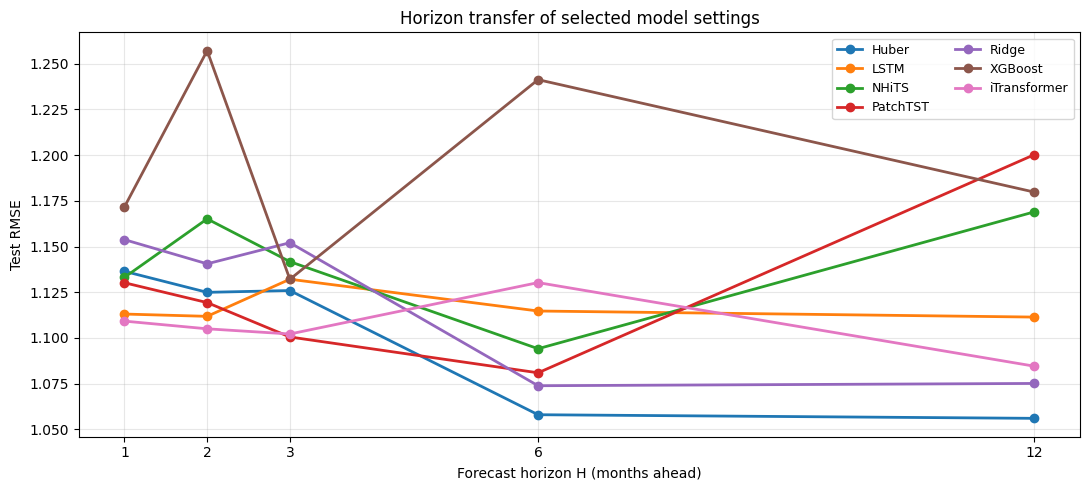

In [8]:
plot_df = model_rmse_pivot.sort_values("H").reset_index(drop=True)
model_columns = [column for column in plot_df.columns if column != "H"]

plt.figure(figsize=(11, 5))
for column in model_columns:
    plt.plot(
        plot_df["H"],
        plot_df[column],
        marker="o",
        linewidth=2,
        label=column.replace("Residual_", ""),
    )

plt.xticks(HORIZONS)
plt.xlabel("Forecast horizon H (months ahead)")
plt.ylabel("Test RMSE")
plt.title("Horizon transfer of selected model settings")
plt.grid(alpha=0.3)
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()
save_current_plot("07_horizon_transfer_rmse_by_horizon.png")
plt.show()

### **Save outputs**

In [9]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

selected_snapshot_path = OUTPUT_DIR / f"{OUTPUT_PREFIX}_selected_settings_snapshot.csv"
metadata_path = OUTPUT_DIR / f"{OUTPUT_PREFIX}_run_metadata.csv"
choice_candidate_long_path = OUTPUT_DIR / f"{OUTPUT_PREFIX}_choice_candidates.csv"
refit_long_path = OUTPUT_DIR / f"{OUTPUT_PREFIX}_refit_test_results.csv"
best_by_horizon_path = OUTPUT_DIR / f"{OUTPUT_PREFIX}_best_by_horizon.csv"
rmse_pivot_path = OUTPUT_DIR / f"{OUTPUT_PREFIX}_rmse_pivot.csv"
mae_pivot_path = OUTPUT_DIR / f"{OUTPUT_PREFIX}_mae_pivot.csv"

selected_settings_df.to_csv(selected_snapshot_path, index=False)
run_metadata_df.to_csv(metadata_path, index=False)
choice_candidate_long_df.to_csv(choice_candidate_long_path, index=False)
refit_test_long_df.to_csv(refit_long_path, index=False)
horizon_summary_df.to_csv(best_by_horizon_path, index=False)
model_rmse_pivot.to_csv(rmse_pivot_path, index=False)
model_mae_pivot.to_csv(mae_pivot_path, index=False)

for path in [
    selected_snapshot_path,
    metadata_path,
    choice_candidate_long_path,
    refit_long_path,
    best_by_horizon_path,
    rmse_pivot_path,
    mae_pivot_path,
]:
    print("Saved:", project_relative(path))

Saved: notebooks_outputs/07_horizon_transfer_selected_model_settings_selected_settings_snapshot.csv
Saved: notebooks_outputs/07_horizon_transfer_selected_model_settings_run_metadata.csv
Saved: notebooks_outputs/07_horizon_transfer_selected_model_settings_choice_candidates.csv
Saved: notebooks_outputs/07_horizon_transfer_selected_model_settings_refit_test_results.csv
Saved: notebooks_outputs/07_horizon_transfer_selected_model_settings_best_by_horizon.csv
Saved: notebooks_outputs/07_horizon_transfer_selected_model_settings_rmse_pivot.csv
Saved: notebooks_outputs/07_horizon_transfer_selected_model_settings_mae_pivot.csv


---

# **Part 4: Conclusion**


### **Overall Takeaways**

- The horizon winner changes with lead time. iTransformer and LSTM are strongest at H=1 and H=2, PatchTST is strongest at H=3, and Huber is strongest at H=6 and H=12.
- This pattern suggests that the selected feature and training settings transfer across horizons, but no single retained model dominates every lead time.
- Huber's strength at H=6 and H=12 is important because it points toward simpler, more stable models becoming competitive as the forecast target moves farther out.
---